In [1]:
from __future__ import annotations

import copy
import pickle
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from typing import Sequence, Optional

from pymatgen.core import Structure

In [2]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent.parent.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT)) 

from muonscripts.constants import constants

from muonscripts.muesr_tools.local_fields import multisite_pfields
from muonscripts.muesr_tools.utils import check_site_distances, get_atom_kinds
from muonscripts.muesr_tools.sample_candidate_sites import sample_anion_muon_sites

from muonscripts.muesr_tools.bayesian import BayesianMomentEstimator

from muonscripts.plot_tools.muon import fancy_style_axes

GAMMA_MU = constants.MUON_GYROMAGNETIC_RATIO/constants.TWOPI
GAMMA_MU *=1e-6 # MHz/T 

In [3]:
def calc_freqdistrib(
    st: Structure,
    magmoms: np.ndarray,
    muon_sites: np.ndarray,
    lorentz_factor: float = 0.0,
    k: Optional[Sequence[float]] = None,
    cont_field: float = 0.0,
    sphere_radius: int = 100
) -> np.ndarray:
    """
    Compute precession frequency per unit moment \nu/\mu (MHz / \mu_B).
    """
    result = multisite_pfields(
        structure=st.copy(),  # Fixed structure argument reference
        magmoms=magmoms,
        muon_positions=muon_sites,
        sphere_r=sphere_radius,
        k=k,
        cont_field=cont_field
    )

    # Total Dipolar + Lorentz field in Tesla per \mu_B
    B = result.dipolar + result.lorentz * lorentz_factor
    B_norm = np.linalg.norm(B, axis=1) 

    # Convert Tesla -> MHz i.e (Tesla /mu_B -> MHz /mu_B)
    nu = B_norm * GAMMA_MU

    return nu

In [4]:
import os
dpath='./'

In [5]:
filename = 'BNOO.cif'
filename = os.path.join(dpath, filename)
p_st = Structure.from_file(filename)
p_st
print(p_st)

Full Formula (Ba8 Na4 Os4 O24)
Reduced Formula: Ba2NaOsO6
abc   :   8.287000   8.287000   8.287000
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (40)
  #  SP         a       b       c
---  ----  ------  ------  ------
  0  Ba    0.25    0.25    0.25
  1  Ba    0.75    0.25    0.25
  2  Ba    0.75    0.75    0.25
  3  Ba    0.25    0.75    0.25
  4  Ba    0.25    0.75    0.75
  5  Ba    0.25    0.25    0.75
  6  Ba    0.75    0.25    0.75
  7  Ba    0.75    0.75    0.75
  8  Na    0.5     0.5     0.5
  9  Na    0.5     0       0
 10  Na    0       0.5     0
 11  Na    0       0       0.5
 12  Os    0       0       0
 13  Os    0       0.5     0.5
 14  Os    0.5     0       0.5
 15  Os    0.5     0.5     0
 16  O     0.2256  0       0
 17  O     0       0.2256  0
 18  O     0.7744  0       0
 19  O     0       0.7744  0
 20  O     0       0       0.2256
 21  O     0       0       0.7744
 22  O     0.2256  0.5     0.5
 23  O     0       0.7256  0.

In [6]:
# Identify atom kinds

atm_kinds = get_atom_kinds(p_st)

print("\nAtom kinds:")
for kind, indices in atm_kinds.items():
    print(f"{kind}: {indices}")


print("\nOs indices:")
print(atm_kinds["Os"])


Atom kinds:
Ba: [0, 1, 2, 3, 4, 5, 6, 7]
Na: [8, 9, 10, 11]
Os: [12, 13, 14, 15]
O: [16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]

Os indices:
[12, 13, 14, 15]


In [7]:
# Inspect Os positions
#
# IMPORTANT:
# This lets us verify the AFM assignment later.

print("\nOs fractional coordinates:")

for i in atm_kinds["Os"]:
    print(
        f"index = {i:3d}   "
        f"frac = {p_st.frac_coords[i]}"
    )



Os fractional coordinates:
index =  12   frac = [0. 0. 0.]
index =  13   frac = [0.  0.5 0.5]
index =  14   frac = [0.5 0.  0.5]
index =  15   frac = [0.5 0.5 0. ]


In [8]:
# Magnetic moment directions
#
# All moments have magnitude 1.
# Therefore the resulting frequency distribution is nu / mu.

dir_111 = np.array([1.0/np.sqrt(3), 1.0/np.sqrt(3), 1.0/np.sqrt(3)])

dir_001 = np.array([0.0, 0.0, 1.0])

print("\nMoment magnitudes:")
print("|dir_111| =", np.linalg.norm(dir_111))
print("|dir_001| =", np.linalg.norm(dir_001))


Moment magnitudes:
|dir_111| = 1.0
|dir_001| = 1.0


In [9]:
# AFM signs used in the present reconstruction
#
# We should verify these against the actual magnetic structure
# once the Os positions / paper figure are checked.

afm_signs = np.array(
    [-1.0, 1.0, 1.0, -1.0]
)

if len(atm_kinds["Os"]) != len(afm_signs):
    raise ValueError(
        "Number of Os sites does not match "
        "the number of AFM signs."
    )


In [10]:
# Construct magnetic structures

magmoms_FM111  = np.zeros((len(p_st), 3))
magmoms_AFM111 = np.zeros_like(magmoms_FM111)
magmoms_AFM001 = np.zeros_like(magmoms_FM111)


# FM [111]
magmoms_FM111[atm_kinds["Os"]] = dir_111

# AFM [111]
magmoms_AFM111[atm_kinds["Os"]] = afm_signs[:, None]* dir_111

# AFM [001]
magmoms_AFM001[atm_kinds["Os"]] = afm_signs[:, None]* dir_001

In [11]:
# Check magnetic moments

for label, moments in {
    "FM111": magmoms_FM111,
    "AFM111": magmoms_AFM111,
    "AFM001": magmoms_AFM001,
}.items():

    print(f"\n{label}")

    for i in atm_kinds["Os"]:
        print(
            f"Os {i:3d}: "
            f"{moments[i]}   "
            f"|m| = {np.linalg.norm(moments[i]):.6f}"
        )


FM111
Os  12: [0.57735027 0.57735027 0.57735027]   |m| = 1.000000
Os  13: [0.57735027 0.57735027 0.57735027]   |m| = 1.000000
Os  14: [0.57735027 0.57735027 0.57735027]   |m| = 1.000000
Os  15: [0.57735027 0.57735027 0.57735027]   |m| = 1.000000

AFM111
Os  12: [-0.57735027 -0.57735027 -0.57735027]   |m| = 1.000000
Os  13: [0.57735027 0.57735027 0.57735027]   |m| = 1.000000
Os  14: [0.57735027 0.57735027 0.57735027]   |m| = 1.000000
Os  15: [-0.57735027 -0.57735027 -0.57735027]   |m| = 1.000000

AFM001
Os  12: [-0. -0. -1.]   |m| = 1.000000
Os  13: [0. 0. 1.]   |m| = 1.000000
Os  14: [0. 0. 1.]   |m| = 1.000000
Os  15: [-0. -0. -1.]   |m| = 1.000000


sample sites and compute freqs/muB for each magnetic configurations

In [12]:
min_cation_distances={
    "Ba": 2.1,
    "Na": 1.63,
    "Os": 2.4,
}  # old

min_cation_distances={
    "Ba": 1.0,
    "Na": 1.0,
    "Os": 1.0,
} # new

seed_no = 42
n_samples = 20000
O_distance = (0.9, 1.10)

candidate_sites = sample_anion_muon_sites(
    p_st.copy(),
    n_samples=n_samples,

    anion_specie=("O",),
    anion_distance=O_distance,

    min_cation_distances=min_cation_distances,

    batch_factor=50,

    seed=seed_no,
)

print(
    f"\nGenerated "
    f"{len(candidate_sites)} "
    f"candidate muon sites."
)


Generated 20000 candidate muon sites.


In [13]:
# Add positions to original structure
p_stc = p_st.copy()
for pos in candidate_sites:
    p_stc.append('H', pos)

file='BNOO_randomsamples_muonsites.cif'
file = os.path.join(dpath, file)
p_stc.to(file)
print(
    f"Saved candidate sites to "
    f"{file}"
)

/home/misah/.virtualenvs/pyqm/lib/python3.10/site-packages/pymatgen/core/structure.py:2945: UserWarning: Site labels are not unique, which is not compliant with the CIF spec (https://www.iucr.org/__data/iucr/cifdic_html/1/cif_core.dic/Iatom_site_label.html):`['Ba1', 'Ba1', 'Ba1', 'Ba1', 'Ba1', 'Ba1', 'Ba1', 'Ba1', 'Na1', 'Na1', 'Na1', 'Na1', 'Os1', 'Os1', 'Os1', 'Os1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'O1', 'H40', 'H41', 'H42', 'H43', 'H44', 'H45', 'H46', 'H47', 'H48', 'H49', 'H50', 'H51', 'H52', 'H53', 'H54', 'H55', 'H56', 'H57', 'H58', 'H59', 'H60', 'H61', 'H62', 'H63', 'H64', 'H65', 'H66', 'H67', 'H68', 'H69', 'H70', 'H71', 'H72', 'H73', 'H74', 'H75', 'H76', 'H77', 'H78', 'H79', 'H80', 'H81', 'H82', 'H83', 'H84', 'H85', 'H86', 'H87', 'H88', 'H89', 'H90', 'H91', 'H92', 'H93', 'H94', 'H95', 'H96', 'H97', 'H98', 'H99', 'H100', 'H101', 'H102', 'H103', 'H104', 'H105', 'H106', 'H107', 

Saved candidate sites to ./BNOO_randomsamples_muonsites.cif


In [14]:
distances = check_site_distances(
    p_st,
    candidate_sites,
)


Site-distance diagnostics:
  Ba: min = 1.8404 Å, max = 3.0241 Å, mean = 2.3009 Å, median = 2.2734 Å
  Na: min = 1.1766 Å, max = 3.2962 Å, mean = 2.3913 Å, median = 2.4473 Å
  Os: min = 1.0000 Å, max = 2.9680 Å, mean = 2.0926 Å, median = 2.1584 Å
   O: min = 0.9000 Å, max = 1.1000 Å, mean = 1.0060 Å, median = 1.0093 Å


In [15]:
# plt.hist(distances["O"], bins=50)
# distances["O"]

In [16]:
# result = multisite_pfields(
#     structure=p_st.copy(),
#     magmoms=magmoms_FM111,
#     muon_positions=candidate_sites,
#     sphere_r=100,
# )

# np.linalg.norm(result.lorentz, axis=1) 
# B = result.dipolar*0 + result.lorentz
# B, np.linalg.norm(B, axis=1) 

check how long to compute freqs

UNCOMMENT LINES

In [17]:
# import time

# for n in [10, 50, 100, 200]:

#     sites = candidate_sites[:n]

#     t0 = time.perf_counter()

#     result = multisite_pfields(
#         structure=p_st.copy(),
#         magmoms=magmoms_FM111,
#         muon_positions=sites,
#         sphere_r=100,
#     )

#     elapsed = time.perf_counter() - t0

#     print(
#         f"{n:6d} muons : "
#         f"{elapsed:8.2f} s  "
#         f"({elapsed / n:.4f} s/muon)"
#     )

# result.dipolar_norm
# result.lorentz_norm * GAMMA_MU

UNCOMMENT LINES BELOW:

Calculate nu / mu

In [18]:
sphere_radius=80
lorentz_factor=0

In [19]:
# print("\nCalculating FM [111]...")

# nu_per_mu_FM111 = calc_freqdistrib(
#     st=p_st.copy(),
#     magmoms=magmoms_FM111,
#     muon_sites=candidate_sites,
#     lorentz_factor=lorentz_factor,
#     sphere_radius=sphere_radius
# )

In [20]:
# print("\nCalculating AFM [111]...")

# nu_per_mu_AFM111 = calc_freqdistrib(
#     st=p_st.copy(),
#     magmoms=magmoms_AFM111,
#     muon_sites=candidate_sites,
#     lorentz_factor=lorentz_factor,
#     sphere_radius=sphere_radius
# )

In [21]:
# print("\nCalculating AFM [001]...")

# nu_per_mu_AFM001 = calc_freqdistrib(
#     st=p_st.copy(),
#     magmoms=magmoms_AFM001,
#     muon_sites=candidate_sites,
#     lorentz_factor=lorentz_factor,
#     sphere_radius=sphere_radius
# )

In [22]:
# # Frequency-distribution diagnostics

# frequency_distributions = {
#     "FM111": nu_per_mu_FM111,
#     "AFM111": nu_per_mu_AFM111,
#     "AFM001": nu_per_mu_AFM001,
# }


# for label, values in frequency_distributions.items():
#     print(f"\n{label}")
#     print(f"  min    = {values.min():.6f}")
#     print(f"  max    = {values.max():.6f}")
#     print(f"  mean   = {values.mean():.6f}")
#     print(f"  median = {np.median(values):.6f}")
#     print(f"  std    = {values.std():.6f}")

saved results:

In [23]:
# BNOO_freqs = {
#     "FM111": nu_per_mu_FM111,
#     "AFM111": nu_per_mu_AFM111,
#     "AFM001": nu_per_mu_AFM001,

#     "sample_sites": candidate_sites,

#     "structure_sites": p_stc,

#     # Store parameters so we know exactly how the data were generated.
#     "parameters": {
#         "n_samples": n_samples,
#         "O_distance": O_distance,
#         "min_cation_distances": min_cation_distances,
#         "sphere_radius": sphere_radius,
#         "seed": seed_no,
#         "lorentz_factor": lorentz_factor,
#     },
# }

# filename = "BNOO_freqs.pkl"
# filename = os.path.join(dpath, filename)
# with open(filename, "wb") as f:
#     pickle.dump(BNOO_freqs, f)

# print(
#     f"\nSaved frequency distributions to "
#     f"{filename}"
# )


load results:

In [24]:
# Load the dictionary back into memory in binary read mode ('rb')
filename = "BNOO_freqs.pkl"
filename = os.path.join(dpath, filename)
with open(filename, "rb") as f:
    loaded_BNOO_freqs = pickle.load(f)

loaded_BNOO_freqs.keys()

dict_keys(['FM111', 'AFM111', 'AFM001', 'sample_sites', 'structure_sites', 'parameters'])

In [25]:
mu_grid = np.linspace(1e-4, 1.0, 4000)

# A. J. Steele et al., Phys. Rev. B 84, 144416 (2011): nu(0)=3.9(1) MHz,
# eta = nu2/nu1 = 0.4(5) -> nu2 = eta*nu1 = 1.56 MHz
expt_freqs = [3.9, 1.56]
expt_errs = [0.1, 0.2]

styles = {
    "FM111": ("r-", "FM [111]"),
    "AFM111": ("b--", "AFM [111]"),
    "AFM001": ("c-.", "AFM [001]"),
}

fontsize=16

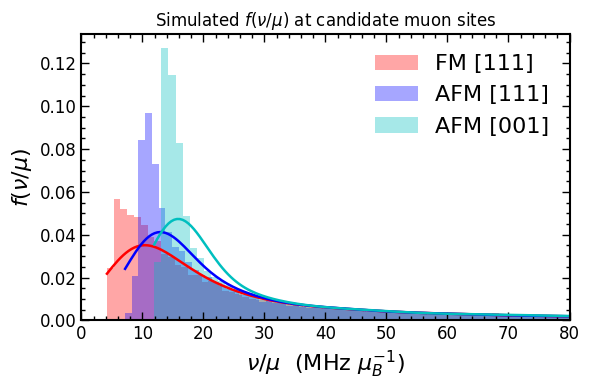

In [26]:
estimators = {label: BayesianMomentEstimator(loaded_BNOO_freqs[label]) for label in styles}

fig_in, ax_in = plt.subplots(figsize=(6, 4))
for label, (style, leglabel) in styles.items():
    color = style[0]
    estimators[label].plot_distribution(ax=ax_in, label=leglabel, color=color)


fancy_style_axes(ax_in)
ax_in.set_xlim(0, 80)
ax_in.legend(frameon=False)
ax_in.legend(
    loc="best", 
    # bbox_to_anchor=(0.5, 1.001), 
    fontsize=fontsize,
    ncol=1, frameon=False, handlelength=1.9, columnspacing=1.2,
)
ax_in.set_title(r"Simulated $f(\nu/\mu)$ at candidate muon sites")
ax_in.set_xlabel(r"$\nu/\mu$  (MHz $\mu_B^{-1}$)", fontsize=fontsize)
ax_in.set_ylabel(r"$f(\nu/\mu)$", fontsize=fontsize)

plt.tight_layout()
fig_name = "field_distributions.png"
fig_name = os.path.join(dpath, fig_name)
plt.savefig(fig_name)
plt.show()

FM111     MAP = 0.262 muB   68% CI = [0.183, 0.330] muB
AFM111    MAP = 0.152 muB   68% CI = [0.119, 0.175] muB
AFM001    MAP = 0.114 muB   68% CI = [0.091, 0.123] muB


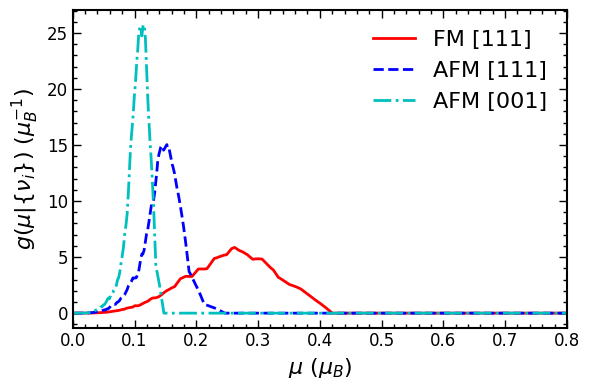

In [27]:
fig, ax = plt.subplots(figsize=(6, 4))
results = {}
for label, (style, leglabel) in styles.items():
    estimator = BayesianMomentEstimator(loaded_BNOO_freqs[label])
    post = estimator.posterior(expt_freqs, expt_errs, mu_grid)
    map_val = estimator.MAP(mu_grid, post)
    ci = estimator.credible_interval(mu_grid, post)
    results[label] = (map_val, ci)
    ax.plot(mu_grid, post, style, lw=2, label=leglabel)
    print(f"{label:8s}  MAP = {map_val:.3f} muB   68% CI = "
          f"[{ci[0]:.3f}, {ci[1]:.3f}] muB")

fancy_style_axes(ax)
ax.set_xlabel(r"$\mu$ ($\mu_B$)", fontsize=fontsize)
ax.set_ylabel(r"$g(\mu|\{\nu_i\})$ ($\mu_B^{-1}$)", fontsize=fontsize)
# ax.set_ylim(0.0, 10)
ax.set_xlim(0.0, 0.8)
ax.legend(frameon=False)
ax.legend(
    loc="best", 
    # bbox_to_anchor=(0.5, 1.001), 
    fontsize=fontsize,
    ncol=1, frameon=False, handlelength=1.9, columnspacing=1.2,
)

plt.tight_layout()
fig_name = "PDF_moments.png"
fig_name = os.path.join(dpath, fig_name)
plt.savefig(fig_name)
plt.show()

In [28]:
try:
    import emcee
    HAVE_EMCEE = True
except ImportError:
    HAVE_EMCEE = False

In [29]:
if HAVE_EMCEE:
    print("\nemcee available -- running MCMC cross-check for FM111...")
    # emcee needs the smooth KDE representation of f(nu/mu); the
    # histogram version has hard zero plateaus that break the sampler.
    est_fm = BayesianMomentEstimator(loaded_BNOO_freqs["FM111"], pdf_method="kde")
    chain, sampler = est_fm.posterior_mcmc(
        expt_freqs, expt_errs, mu0=results["FM111"][0], seed=1
    )

    print(f"  emcee : mean = {chain.mean():.3f} muB, "
          f"std = {chain.std():.3f} muB, "
          f"median = {np.median(chain):.3f} muB, "
          f"mean acceptance fraction = "
          f"{np.mean(sampler.acceptance_fraction):.2f}")
    print(f"  grid  : MAP  = {results['FM111'][0]:.3f} muB, "
          f"68% CI = [{results['FM111'][1][0]:.3f}, "
          f"{results['FM111'][1][1]:.3f}] muB")

    fig_mc, ax_mc = plt.subplots(figsize=(6, 4))
    ax_mc.plot(mu_grid, estimators["FM111"].posterior(expt_freqs, expt_errs, mu_grid),
               "r-", lw=2, label="grid (exact)")
    ax_mc.hist(chain, bins=80, density=True, histtype="step", lw=2,
               color="k", label="emcee")
    ax_mc.set_xlabel(r"$\mu$ ($\mu_B$)")
    ax_mc.set_ylabel(r"$g(\mu|\{\nu_i\})$ ($\mu_B^{-1}$)")
    ax_mc.set_xlim(0.0, 0.8)
    ax_mc.legend(frameon=False)
    plt.tight_layout()
else:
    print("\nemcee not installed -- skipping MCMC cross-check "
          "(not needed: the grid posterior above is already exact "
          "for this 1-D problem).")

plt.show()


emcee not installed -- skipping MCMC cross-check (not needed: the grid posterior above is already exact for this 1-D problem).
